<a href="https://colab.research.google.com/github/LeonimerMelo/Machine_Learning/blob/DBSCAN/DBSCAN_Clustering_Algorithm_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN: Clusterização por Densidade

## O Problema da Clusterização

Imagine que você tem um monte de pontos em um gráfico e quer agrupar aqueles que são "parecidos". Esse é o objetivo da **clusterização (agrupamento)** em Machine Learning.

Os algoritmos tradicionais como **K-Means** funcionam bem quando os grupos têm formato de **bolha** (esféricos) e tamanhos semelhantes. Mas e se os dados tiverem formatos estranhos, como **curvas, espirais ou anéis**? É aí que o DBSCAN pode ajudar!

## A Ideia Central do DBSCAN

**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) tem uma lógica simples e intuitiva:

> **"Um cluster é uma região do espaço onde os pontos estão densamente agrupados, separados por regiões de baixa densidade."**

Funciona como um **efeito dominó**:
1. Escolha um ponto qualquer.
2. Veja se ele tem **vizinhos suficientes** dentro de um **raio**.
3. Se sim, ele é um "ponto central" e começa um cluster.
4. Todos os vizinhos desse ponto também são incluídos no cluster.
5. Repita o processo para cada vizinho, expandindo o cluster como uma mancha que cresce.
6. Pontos que não pertencem a nenhum cluster são **outliers (ruído)**.


## Os 3 Tipos de Pontos no DBSCAN

| Tipo | Definição | Exemplo |
|------|-----------|---------|
| **Ponto Central** | Tem pelo menos `min_samples` vizinhos dentro do raio `eps` | Uma pessoa com muitos amigos próximos |
| **Ponto de Borda** | Tem menos de `min_samples` vizinhos, MAS está perto de um ponto central | Um amigo distante de um grupo popular |
| **Outlier (Ruído)** | Não é central nem borda de nenhum cluster | Um solitário que não se encaixa em nenhum grupo |

```
Visualização:
         ● (Central)     ○ (Borda)
    ★ (Outlier)
    
    ● ● ● ● ○
    ● ● ● ● ●  ← Região densa (Cluster)
      ○   ★    ← Região esparsa (Ruído)
```

## Vantagens do DBSCAN

### **Não exige número de clusters**
- **K-Means**: Você precisa dizer "quero 5 grupos".
- **DBSCAN**: Descobre sozinho quantos grupos existem!

### **Encontra formatos arbitrários**
- **K-Means**: Só encontra clusters redondos.
- **DBSCAN**: Encontra curvas, espirais, anéis, qualquer formato!

```
K-Means falha em:          DBSCAN acerta em:
    🌙🌙                        🌙🌙
   (meias-luas)              (meias-luas)
```

### **Identifica outliers automaticamente**
- **K-Means**: Força todos os pontos a pertencerem a algum cluster.
- **DBSCAN**: Marca pontos isolados como ruído (-1).

### **Robusto a dados com ruído**
- Ótimo para datasets do mundo real, que sempre têm dados esquisitos ou erros de medição.

### **Interpretabilidade**
- Os parâmetros `eps` e `min_samples` são intuitivos e têm significado físico (distância e densidade).

## Desvantagens do DBSCAN

### **Sensível aos parâmetros**
- Escolher `eps` e `min_samples` é uma **arte**!
- `eps` muito grande → tudo vira um cluster só.
- `eps` muito pequeno → cada ponto vira seu próprio cluster.
- `min_samples` muito alto → muitos pontos viram ruído.

### **Não funciona com densidades muito variadas**
- Se um cluster é muito denso e outro é esparso, o DBSCAN pode:
  - Perder o cluster esparso (se `eps` for pequeno)
  - Fundir os dois clusters (se `eps` for grande)

```
Problema: Cluster A (denso) e Cluster B (esparso)
    ●●●●●●        ○  ○  ○
    ●●●●●●        ○  ○  ○
    (denso)       (esparso)
    
DBSCAN tem dificuldade em ajustar para ambos!
```

### **Escala importa!**
- DBSCAN usa distâncias (Euclidiana por padrão).
- Dados em escalas diferentes precisam ser **padronizados** (StandardScaler).

### **Complexidade computacional**
- **Pior caso:** O(n²) - pode ser lento para milhões de pontos.
- **Com índices espaciais:** O(n log n) - mas ainda mais lento que K-Means (O(n)).

### **Dados de alta dimensão**
- Em espaços com muitas dimensões, a noção de "distância" perde o sentido.
- Todos os pontos ficam igualmente distantes uns dos outros.

## Comparação com Outros Algoritmos

| Característica | **DBSCAN** | **K-Means** | **Agglomerative** | **Gaussian Mixture** |
|----------------|------------|-------------|-------------------|----------------------|
| **Nº de clusters** | Descobre | Define k | Define k | Define k |
| **Formato dos clusters** | Qualquer | Esférico | Qualquer | Elipsoidal |
| **Outliers** | Detecta | Não detecta | Não detecta | Detecta (probabilístico) |
| **Funciona com densidades variadas** | Não | Sim | Sim | Sim |
| **Escalabilidade** | Médio | Alto | Médio | Médio |
| **Facilidade de uso** | Médio | Fácil | Médio | Difícil |
| **Interpretabilidade** | Alta | Alta | Alta | Baixa |

## Exemplo do Mundo Real: Quando Usar Cada Um?

| Situação | Melhor Algoritmo | Por quê? |
|----------|------------------|----------|
| Segmentar clientes por compras | **K-Means** | Clientes formam grupos naturais (alto/baixo gasto) |
| Encontrar tipos de galáxias | **DBSCAN** | Formatos arbitrários, muitas galáxias são ruído |
| Agrupar pixels de uma imagem | **DBSCAN** | Formas irregulares (objetos na imagem) |
| Análise de documentos de texto | **K-Means** | Dados de alta dimensão (DBSCAN sofre) |
| Detectar fraudes em transações | **DBSCAN** | Fraudes são outliers - DBSCAN as identifica! |
| Biologia (agrupar espécies) | **Agglomerative** | Hierarquia natural (espécies → gêneros → famílias) |








## Resumo

```
                    DBSCAN em 3 Passos:
                    
    1. Escolha eps e min_samples
              ↓
    2. Encontre pontos centrais (densos)
              ↓
    3. Expanda clusters a partir dos centrais
              ↓
    Resultado: Clusters + Outliers!
```

## Conclusão

O **DBSCAN** é como um **detetive de aglomerações**:
- **Forças:** Encontra grupos de qualquer forma, detecta outliers, não precisa de número prévio de clusters.
- **Fraquezas:** Sensível a parâmetros, não lida bem com densidades muito diferentes, sofre em alta dimensão.

**Use DBSCAN quando:**
- Você não sabe quantos clusters existem.
- Seus dados têm formatos não-esféricos.
- Você quer identificar outliers naturalmente.

**Evite DBSCAN quando:**
- Seus dados têm muitas dimensões (>10).
- As densidades dos clusters variam muito.
- Você tem milhões de pontos (a menos que use versões otimizadas).

> **Dica Final:** Sempre normalize/padronize os dados antes de usar DBSCAN! A escala das *features* influencia diretamente as distâncias e, consequentemente, o resultado do algoritmo.

##Exemplo de utilização do algoritmo **DBSCAN**
Vamos criar um conjunto de dados com **formato de "meia-lua"** (dois clusters crescentes) e alguns **outliers** para demonstrar como o DBSCAN identifica agrupamentos de formato arbitrário e pontos ruidosos.

In [11]:
# Preparação do Ambiente
# =====================================================
# IMPORTAÇÃO DAS BIBLIOTECAS NECESSÁRIAS
# =====================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Função auxiliar para visualização
def plot_clusters(X, labels, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot com clusters
    unique_labels = set(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'gray'
            label = 'Outliers'
        else:
            label = f'Cluster {k}'

        mask = (labels == k)
        ax1.scatter(X[mask, 0], X[mask, 1], c=[col],
                   label=label, s=30, alpha=0.7)

    ax1.set_title(f'{title} - Visualização Original')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot com PCA (para dados multidimensionais)
    if X.shape[1] > 2:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = 'gray'
            mask = (labels == k)
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=[col], s=30, alpha=0.7)
        ax2.set_title('Visualização com PCA (2D)')
        ax2.grid(True, alpha=0.3)
    else:
        ax2.remove()

    plt.tight_layout()
    plt.show()

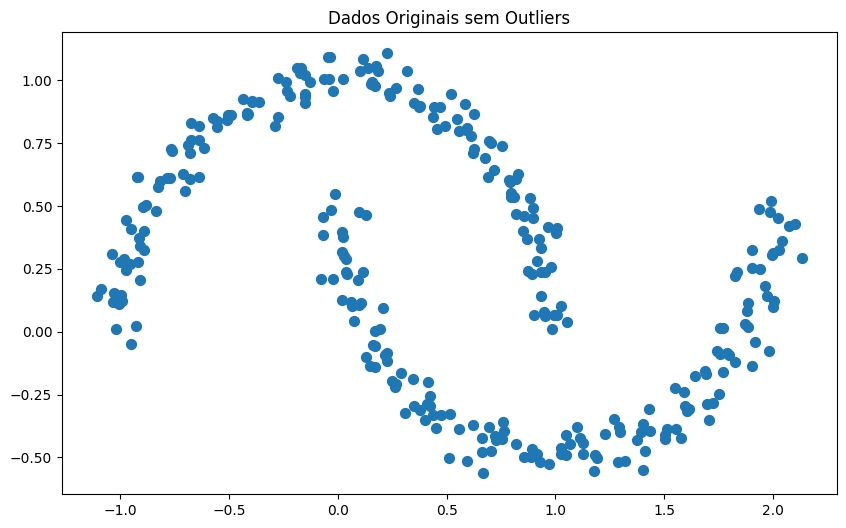

In [ ]:
# =====================================================
# CRIAÇÃO DO CONJUNTO DE DADOS SINTÉTICO
# =====================================================
# Gerando 300 pontos com formato de duas meias-luas (clusters entrelaçados)
# noise=0.05 adiciona uma pequena dispersão para tornar o problema mais realista
X_moons, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Plot dos dados sem rótulos que serão utilizados no DBSCAN
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0],X_moons[:, 1], s=50)
plt.title("Dados Originais sem Outliers")
plt.show()

INSERINDO OUTLIERS NO DATASET
Total de pontos no dataset: 315
  - Pontos originais (meias-luas): 300
  - Outliers inseridos: 15



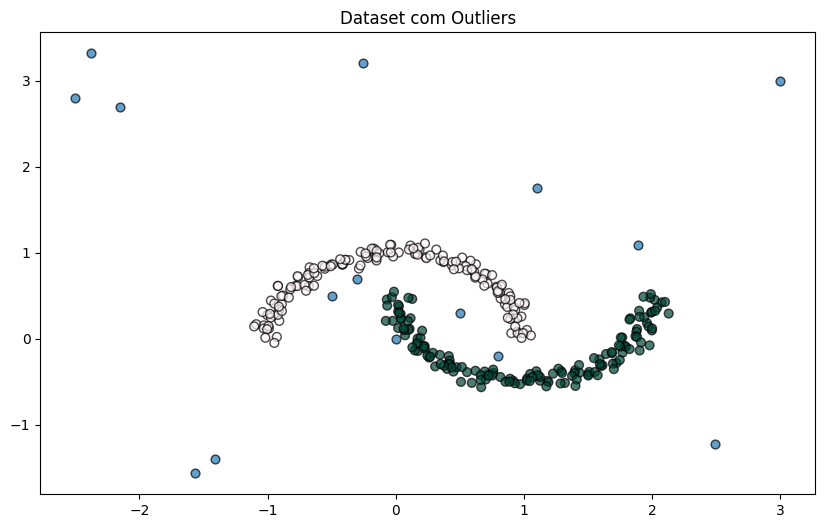

In [ ]:
# =====================================================
# INSERÇÃO DE OUTLIERS INTENCIONAIS
# =====================================================
print("=" * 60)
print("INSERINDO OUTLIERS NO DATASET")
print("=" * 60)

# Definindo semente aleatória para reprodutibilidade
np.random.seed(42)

# Criando 15 outliers em posições estratégicas
n_outliers = 15

# Outlier tipo 1: Pontos distantes (longe dos clusters)
outliers_distantes = np.random.uniform(low=-2.5, high=3.5, size=(8, 2))

# Outlier tipo 2: Pontos entre os dois clusters (região de fronteira)
outliers_fronteira = np.array([
    [0.0, 0.0],
    [0.5, 0.3],
    [-0.3, 0.7],
    [0.8, -0.2],
    [-0.5, 0.5]
])

# Outlier tipo 3: Pontos muito afastados em uma direção específica
outliers_afastados = np.array([
    [3.0, 3.0],
    [-2.5, 2.8]
])

# Combinando todos os outliers
outliers = np.vstack([outliers_distantes, outliers_fronteira, outliers_afastados])

# Garantindo que temos exatamente n_outliers
outliers = outliers[:n_outliers]

# Concatenando os dados originais com os outliers
X = np.vstack([X_moons, outliers])

print(f"Total de pontos no dataset: {len(X)}")
print(f"  - Pontos originais (meias-luas): {len(X_moons)}")
print(f"  - Outliers inseridos: {len(outliers)}")
print()

# Plotando os dados brutos
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_true, cmap='PuBuGn', s=40, alpha=.7, edgecolors='k')
plt.scatter(outliers[:, 0], outliers[:, 1], s=40, alpha=.7, edgecolors='k')
plt.title("Dataset com Outliers")
plt.show()

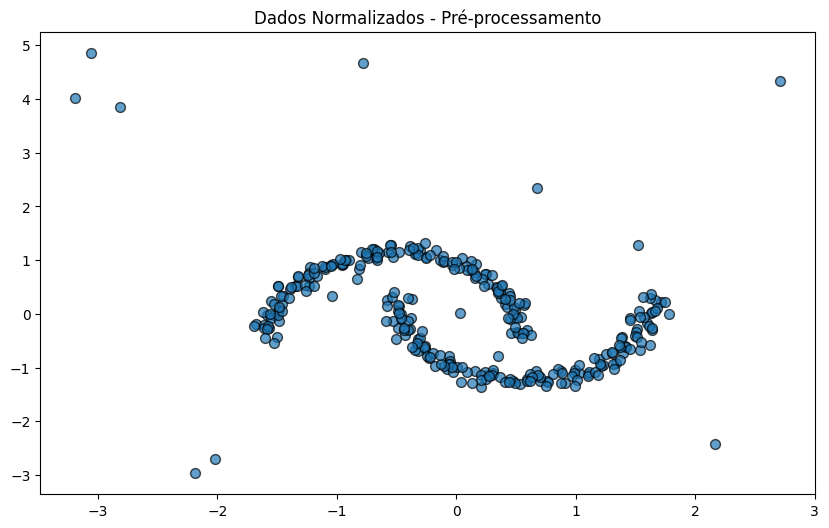

In [ ]:
# Padronizando (normalizando) os dados (importante para o DBSCAN, pois a distância é sensível à escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plotando os dados brutos
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=50, alpha=.7, edgecolors='k')
plt.title("Dados Normalizados - Pré-processamento")
plt.show()

### Escolha dos Parâmetros do DBSCAN
**Método Prático (Elbow Method)**

O `n_neighbors` no método do cotovelo representa quantos vizinhos considerar para determinar a densidade local. Ele está diretamente relacionado ao `min_samples` do DBSCAN.

**Relação Fundamental**:
`n_neighbors ≈ min_samples - 1`

Por quê?

- O DBSCAN usa min_samples (incluindo o próprio ponto)
- O NearestNeighbors usa n_neighbors (excluindo o próprio ponto)
- Portanto: n_neighbors = min_samples - 1

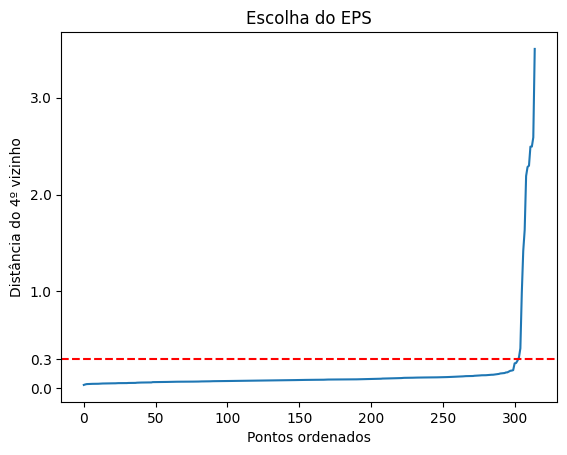

In [ ]:
# Calcula distâncias dos k-vizinhos mais próximos
neigh = NearestNeighbors(n_neighbors=4)
neigh.fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
distances = np.sort(distances[:, 3])  # 4º vizinho mais próximo

# Plota o gráfico do "cotovelo"
plt.plot(distances)
plt.axhline(y=.3, color='r', linestyle='--')
plt.yticks([0, .3, 1, 2, 3])
plt.xlabel("Pontos ordenados")
plt.ylabel("Distância do 4º vizinho")
plt.title("Escolha do EPS")
plt.show()

Onde está o "cotovelo" (ponto de inflexão) é o valor ideal para `eps`!

**Regra para `min_samples`:**
- **≥ D + 1** (D = número de dimensões)
- Para 2D: use 3-5
- Para dados ruidosos: use 10-20
- Quanto maior, menos clusters e mais ruído

In [ ]:
# =====================================================
# APLICAÇÃO DO DBSCAN
# =====================================================
# Parâmetros:
#   eps = 0.3  → raio de vizinhança (distância máxima para considerar um ponto como vizinho)
#   min_samples = 5 → número mínimo de pontos para formar uma região densa (incluindo o próprio ponto)
# dbscan = DBSCAN(eps=0.2, min_samples=3)  # Mais clusters, menos ruído
# dbscan = DBSCAN(eps=0.5, min_samples=10) # Menos clusters, mais ruído
dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# O resultado 'clusters' é um array onde:
#   - valores >= 0 indicam o ID do cluster (0, 1, 2, ...)
#   - valor -1 indica outlier (ponto considerado ruído)

# =====================================================
# ANÁLISE DOS RESULTADOS
# =====================================================
# Número total de clusters encontrados (excluindo o ruído)
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_outliers_detectados = np.sum(clusters == -1)

print("=" * 60)
print("RESULTADOS DO DBSCAN")
print("=" * 60)
print(f"Clusters encontrados: {n_clusters}")
print(f"Outliers detectados: {n_outliers_detectados}")
print(f"Outliers inseridos: {n_outliers}")
print(f"Taxa de detecção de outliers: {n_outliers_detectados/n_outliers*100:.1f}%")
print(f"Rótulos atribuídos (amostra): {clusters[:10]}")  # Mostra os 10 primeiros

RESULTADOS DO DBSCAN
Clusters encontrados: 2
Outliers detectados: 11
Outliers inseridos: 15
Taxa de detecção de outliers: 73.3%
Rótulos atribuídos (amostra): [0 0 0 1 0 0 0 1 1 0]


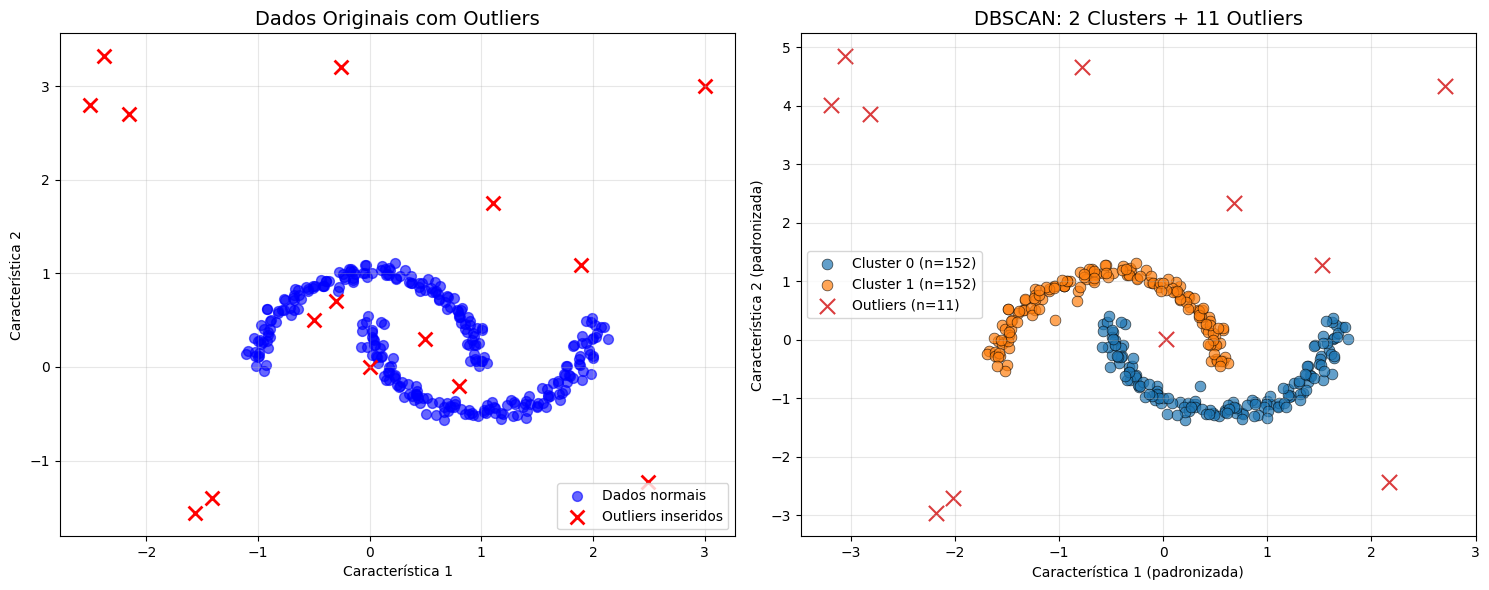

In [ ]:
# =====================================================
# VISUALIZAÇÃO DOS RESULTADOS
# =====================================================
# Criando uma figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot 1: Dados originais com outliers destacados ---
ax1.scatter(X_moons[:, 0], X_moons[:, 1],
            c='blue', label='Dados normais',
            alpha=0.6, s=50)
ax1.scatter(outliers[:, 0], outliers[:, 1],
            c='red', label='Outliers inseridos',
            s=100, marker='x', linewidths=2)
ax1.set_title("Dados Originais com Outliers", fontsize=14)
ax1.set_xlabel("Característica 1")
ax1.set_ylabel("Característica 2")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Definindo cores: dois clusters + outliers em vermelho
cores = {
    0: '#1f77b4',  # Azul
    1: '#ff7f0e',  # Laranja
    -1: '#d62728'  # Vermelho (outliers)
}

# --- Subplot 2: Resultado do DBSCAN ---
# Plotando cada grupo
for rotulo in set(clusters):
    mask = (clusters == rotulo)
    if rotulo == -1:
        label = f"Outliers (n={sum(mask)})"
        marker = 'x'
        tamanho = 120
        alpha = 0.9
        ax2.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c=cores[rotulo], label=label,
                    s=tamanho, marker=marker,
                    alpha=alpha)
    else:
        label = f"Cluster {rotulo} (n={sum(mask)})"
        marker = 'o'
        tamanho = 60
        alpha = 0.7
        ax2.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c=cores[rotulo], label=label,
                    s=tamanho, marker=marker,
                    edgecolors='black', linewidth=0.5, alpha=alpha)

ax2.set_title(f"DBSCAN: {n_clusters} Clusters + {n_outliers_detectados} Outliers", fontsize=14)
ax2.set_xlabel("Característica 1 (padronizada)")
ax2.set_ylabel("Característica 2 (padronizada)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**CONCEITOS FUNDAMENTAIS DO DBSCAN**:

1. eps (épsilon) - Raio de vizinhança:
   - Define a distância máxima para considerar dois pontos como vizinhos.
   - Pontos dentro desse raio são "alcançáveis" uns dos outros.
   - No exemplo, eps=0.3 significa que pontos a até 0.3 de distância (escala padronizada) são vizinhos.

2. min_samples - Número mínimo de pontos:
   - Quantos pontos (incluindo o próprio) precisam estar dentro do raio eps para formar uma região densa.
   - Se um ponto tem pelo menos min_samples vizinhos dentro de eps, ele é um "ponto central".
   - No exemplo, min_samples=5 → precisamos de 5 pontos próximos para iniciar um cluster.

3. Classificação dos pontos:
   - Ponto Central: tem >= min_samples vizinhos dentro de eps.
   - Ponto de Borda: tem < min_samples vizinhos, mas está dentro do eps de um ponto central.
   - Outlier (Ruído): não é central nem borda de nenhum cluster.

4. Vantagens do DBSCAN:
   - Não exige número prévio de clusters (diferente do K-Means).
   - Encontra clusters de formato arbitrário (não apenas esféricos).
   - Identifica automaticamente outliers (ruído).

5. Desvantagens:
   - Sensível à escolha de eps e min_samples.
   - Não funciona bem com densidades muito diferentes entre clusters.
   - Pode ser caro computacionalmente para datasets grandes (O(n²) no pior caso).

##Exemplo multivariáveis DBSCAN

Gerando dados com formatos complexos



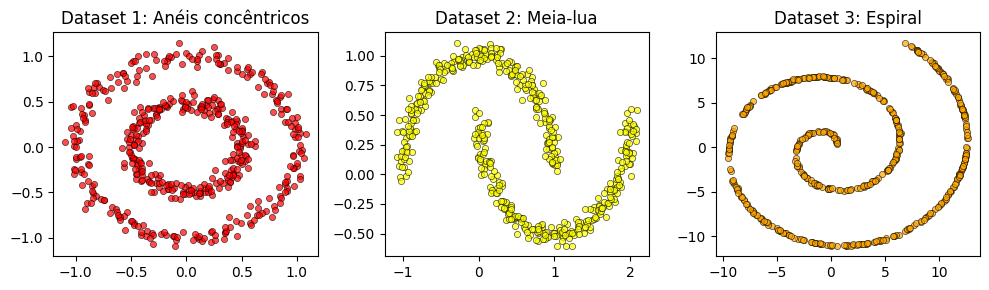

In [6]:
# Preparação do Ambiente
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.datasets import make_swiss_roll

# 1.1 Gerar diferentes datasets
print("Gerando dados com formatos complexos")
print()

# Dataset 1: Anéis concêntricos
X_circles, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Dataset 2: Meia-lua
X_moons, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

# Dataset 3: Espiral (criando manualmente)
def make_spiral(n_samples=500, noise=0.1):
    n = np.sqrt(np.random.rand(n_samples)) * 780 * (2*np.pi)/360
    x = n * np.cos(n) + np.random.randn(n_samples) * noise
    y = n * np.sin(n) + np.random.randn(n_samples) * noise
    return np.column_stack([x, y])

X_spiral = make_spiral(500, noise=0.05)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].scatter(X_circles[:, 0], X_circles[:, 1], c='red', s=20, edgecolors='black', linewidth=0.5, alpha=.7)
axs[0].set_title("Dataset 1: Anéis concêntricos")
axs[1].scatter(X_moons[:, 0], X_moons[:, 1], c='yellow', s=20, edgecolors='black', linewidth=0.5, alpha=.7)
axs[1].set_title("Dataset 2: Meia-lua")
axs[2].scatter(X_spiral[:, 0], X_spiral[:, 1], c='orange', s=20, edgecolors='black', linewidth=0.5, alpha=.7)
axs[2].set_title("Dataset 3: Espiral")
plt.tight_layout()
plt.show()

In [7]:
# 1.2 Aplicar DBSCAN em cada dataset e comparar resultados
datasets = [
    (X_circles, "Anéis Concêntricos"),
    (X_moons, "Meia-Lua"),
    (X_spiral, "Espiral")
]

# Padronizar dados
for X, name in datasets:
    X_scaled = StandardScaler().fit_transform(X)

    # Aplicar DBSCAN com diferentes parâmetros
    print(f"\n{'='*50}")
    print(f"Dataset: {name}")
    print(f"Dimensões: {X.shape}")

    # Testar diferentes combinações de parâmetros
    param_combinations = [
        (0.1, 5),
        (0.2, 5),
        (0.3, 5),
        (0.3, 10)
    ]

    for eps, min_samples in param_combinations:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_outliers = np.sum(labels == -1)

        print(f"  eps={eps}, min_samples={min_samples}:")
        print(f"    Clusters: {n_clusters}, Outliers: {n_outliers}")

        if n_clusters > 1 and n_outliers < len(X)*0.3:
            # Calcular silhouette score apenas se tiver mais de 1 cluster
            try:
                score = silhouette_score(X_scaled[labels != -1],
                                        labels[labels != -1])
                print(f"    Silhouette Score: {score:.3f}")
            except:
                pass


Dataset: Anéis Concêntricos
Dimensões: (500, 2)
  eps=0.1, min_samples=5:
    Clusters: 24, Outliers: 247
  eps=0.2, min_samples=5:
    Clusters: 5, Outliers: 3
    Silhouette Score: 0.123
  eps=0.3, min_samples=5:
    Clusters: 2, Outliers: 0
    Silhouette Score: 0.113
  eps=0.3, min_samples=10:
    Clusters: 2, Outliers: 0
    Silhouette Score: 0.113

Dataset: Meia-Lua
Dimensões: (500, 2)
  eps=0.1, min_samples=5:
    Clusters: 15, Outliers: 48
    Silhouette Score: 0.247
  eps=0.2, min_samples=5:
    Clusters: 2, Outliers: 0
    Silhouette Score: 0.389
  eps=0.3, min_samples=5:
    Clusters: 2, Outliers: 0
    Silhouette Score: 0.389
  eps=0.3, min_samples=10:
    Clusters: 2, Outliers: 0
    Silhouette Score: 0.389

Dataset: Espiral
Dimensões: (500, 2)
  eps=0.1, min_samples=5:
    Clusters: 16, Outliers: 11
    Silhouette Score: 0.488
  eps=0.2, min_samples=5:
    Clusters: 3, Outliers: 0
    Silhouette Score: 0.104
  eps=0.3, min_samples=5:
    Clusters: 1, Outliers: 0
  eps=0.

##Métrica `silhouette_score`
O resultado do silhouette_score mede o quão bem agrupados e separados estão os seus dados. Ele varia estritamente entre -1 e +1. [1, 2]

**Interpretando os Valores**
* De +0.71 a +1.00 (Excelente): Os clusters estão perfeitamente separados. Cada ponto está muito perto do centro do seu próprio grupo e muito longe dos grupos vizinhos.
* De +0.51 a +0.70 (Bom): Estrutura de cluster razoável e perceptível. Os pontos estão predominantemente nos lugares certos. [3]
* De +0.26 a +0.50 (Fraco/Raso): Os grupos estão muito próximos ou se sobrepõem bastante. A estrutura dos dados é fraca ou o número de clusters escolhido não é o ideal. [4]
* De -0.25 a +0.25 (Sem estrutura): Os dados parecem ruído ou uma massa única. O algoritmo não conseguiu encontrar divisões claras. [5]
* Valores Negativos (Até -1.00): Pior cenário possível. Significa que os pontos foram colocados nos clusters errados (estão mais perto do cluster vizinho do que do próprio).

O score calcula uma média matemática que equilibra dois fatores fundamentais:

* Coesão (Proximidade interna): O quão próximos os pontos de um mesmo grupo estão entre si. Quanto menor essa distância interna, melhor.
* Separação (Distância externa): O quão distantes os grupos estão uns dos outros. Quanto maior a distância até o grupo vizinho mais próximo, melhor. [6, 7]

Um score alto funciona muito bem para formatos arredondados ou esféricos (como os gerados pelo K-Means). Se os seus dados tiverem formatos complexos ou geométricos (como duas luas ou círculos concêntricos), o algoritmo DBSCAN ou Spectral Clustering pode achar os grupos perfeitos, mas o silhouette_score ainda assim dar um valor baixo.

[1] [https://www.datacamp.com](https://www.datacamp.com/pt/tutorial/silhouette-score)

[2] [https://pt.linkedin.com](https://pt.linkedin.com/pulse/silhouette-score-para-avaliar-qualidade-dos-clusters-algoritmo-parra)

[3] [https://www.datacamp.com](https://www.datacamp.com/pt/tutorial/silhouette-score)

[4] [https://www.datacamp.com](https://www.datacamp.com/pt/tutorial/silhouette-score)

[5] [https://www.instagram.com](https://www.instagram.com/p/DWRe3tCjZBD/)

[6] [https://www.datacamp.com](https://www.datacamp.com/pt/tutorial/silhouette-score)

[7] [https://www.alura.com.br](https://www.alura.com.br/artigos/metricas-de-avaliacao-para-clusterizacao)


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 1. Generate or load your dataset
X = np.random.rand(100, 5)

# 2. Fit your clustering model
kmeans = KMeans(n_clusters=3, random_state=42)
predict_labels = kmeans.fit_predict(X)

# 3. Calculate the Silhouette Score
score = silhouette_score(X, predict_labels, metric='euclidean')
print(f"Silhouette Score: {score}")


Silhouette Score: 0.16762926637388745


### silhouette_score metric parameter
Para encontrar o melhor parâmetro para a métrica de distância (metric), você precisa alinhar o tipo dos seus dados com testes práticos baseados no próprio silhouette_score.
A métrica padrão é a 'euclidean' (Euclidiana), mas ela não serve para todos os cenários.

**Escolha pelo Tipo de Dado (Regra de Ouro)**

Antes de rodar códigos, filtre as métricas candidatas com base na natureza dos seus dados:

* Dados Contínuos/Numéricos Tradicionais: Use 'euclidean' ou 'manhattan'.
* Dica: Se os seus dados possuem muitas dimensões (muitas colunas) ou muitos outliers, a 'manhattan' costuma funcionar melhor que a Euclidiana.
* Dados de Texto ou Contagem (Frequência): Use 'cosine' (Distância de Cosseno). Ela foca no ângulo entre os vetores e ignora a diferença de magnitude ou tamanho do texto.
* Dados Binários (Sim/Não, 0/1): Use 'hamming' ou 'jaccard'. Elas medem a proporção de características que diferem entre os registros.

**Otimização Automatizada (Procura em Grade)**

A forma matemática e empírica de definir a melhor métrica é testar um conjunto de candidatas dentro do seu algoritmo e ver qual delas entrega o maior silhouette_score.
Abaixo está um exemplo de código para automatizar essa busca.
Nota importante: Para que a comparação seja justa, o algoritmo de clusterização (como o AgglomerativeClustering) deve usar a mesma métrica que você vai passar para o silhouette_score. O KMeans tradicional só aceita distância Euclidiana internamente, por isso usamos o agrupamento hierárquico.

**Avalie o significado físico da distância**

Nem sempre o maior score vence isoladamente. Você deve se perguntar: “Faz sentido para o meu negócio usar essa distância?”

Exemplo: Se você está agrupando clientes pelo histórico de compras e quer ignorar se um cliente gasta 10 reais e o outro 1.000 reais, focando apenas em quais produtos eles compram proporcionalmente, a métrica 'cosine' é logicamente superior, mesmo que a 'euclidean' dê um score ligeiramente maior no teste.




In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Supondo que 'X' sejam seus dados já padronizados (StandardScaler)
X = np.random.rand(100, 5)

# Lista de métricas que fazem sentido para o seu tipo de dado
metricas_candidatas = ['euclidean', 'manhattan', 'cosine']
resultados = []

for metrica in metricas_candidatas:
    try:
        # Treina o modelo usando a métrica específica
        modelo = AgglomerativeClustering(n_clusters=3, metric=metrica, linkage='average')
        labels = modelo.fit_predict(X)

        # Calcula o score usando a MESMA métrica de distância
        score = silhouette_score(X, labels, metric=metrica)

        resultados.append({'Métrica': metrica, 'Silhouette Score': score})
    except Exception as e:
        print(f"Não foi possível calcular com a métrica {metrica}: {e}")

# Transforma em DataFrame para ordenar e visualizar facilmente
df_resultados = pd.DataFrame(resultados).sort_values(by='Silhouette Score', ascending=False)
print(df_resultados)


     Métrica  Silhouette Score
2     cosine          0.271776
1  manhattan          0.178822
0  euclidean          0.118073


**BASE DE DADOS DE GEOGRAFIA**

Dados sintéticos que simulam localizações geográficas (cidades) e aplicar DBSCAN para encontrar regiões densas.

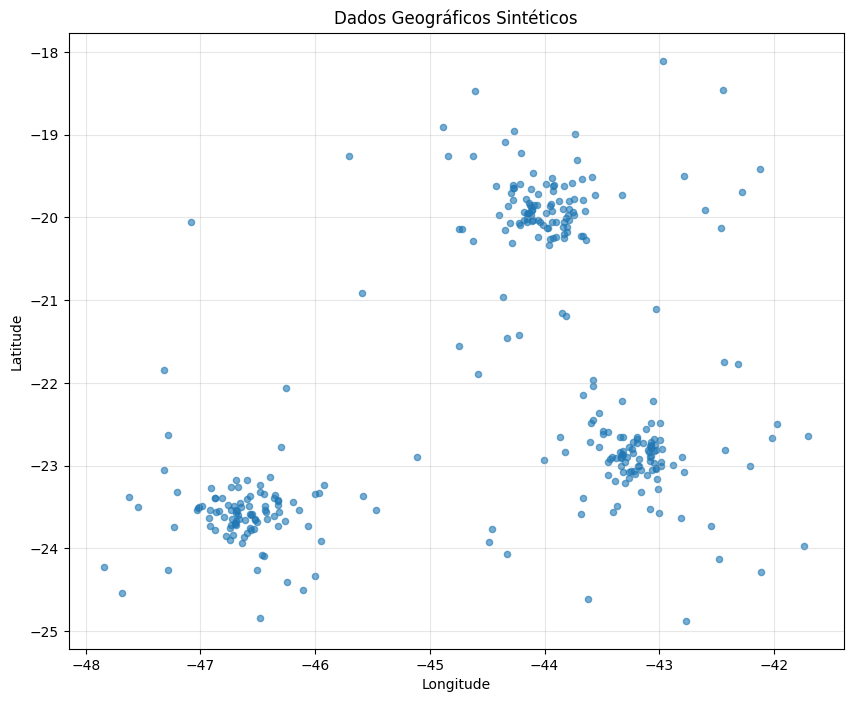

In [14]:
# Criar dados sintéticos geográficos
np.random.seed(42)

# Centro de 3 cidades
cities = {
    'São Paulo': (-23.55, -46.63),
    'Rio de Janeiro': (-22.91, -43.20),
    'Belo Horizonte': (-19.92, -43.94)
}

# Gerar pontos ao redor de cada cidade (com ruído)
n_points_per_city = 100
points = []

for city, (lat, lon) in cities.items():
    # Adicionar alguns pontos densos (centro)
    for _ in range(70):
        lat_noise = np.random.normal(0, 0.2)
        lon_noise = np.random.normal(0, 0.2)
        points.append([lat + lat_noise, lon + lon_noise])

    # Adicionar pontos esparsos (periferia)
    for _ in range(30):
        lat_noise = np.random.normal(0, 0.8)
        lon_noise = np.random.normal(0, 0.8)
        points.append([lat + lat_noise, lon + lon_noise])

# Adicionar alguns outliers
for _ in range(20):
    lat = np.random.uniform(-25, -18)
    lon = np.random.uniform(-48, -42)
    points.append([lat, lon])

X_geo = np.array(points)

# 5.2 Visualizar dados
plt.figure(figsize=(10, 8))
plt.scatter(X_geo[:, 1], X_geo[:, 0], s=20, alpha=0.6)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Dados Geográficos Sintéticos")
plt.grid(True, alpha=0.3)
plt.show()


Método do cotovelo


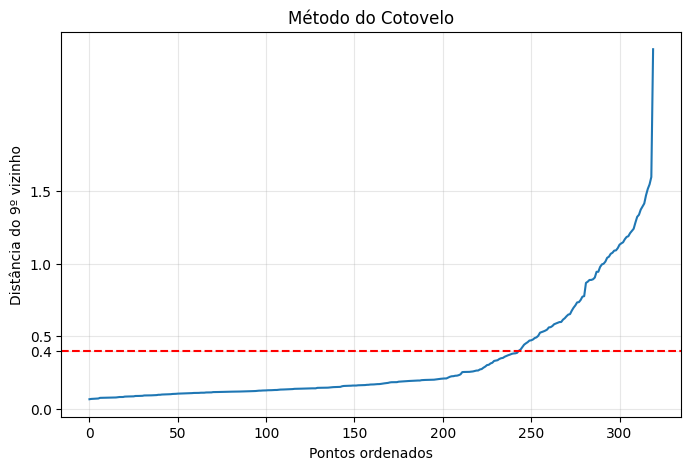

In [15]:
# Usar o método do cotovelo
print('\nMétodo do cotovelo')
neigh = NearestNeighbors(n_neighbors=9)
neigh.fit(X_geo)
distances, _ = neigh.kneighbors(X_geo)
distances = np.sort(distances[:, 8])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Pontos ordenados")
plt.ylabel("Distância do 9º vizinho")
plt.title("Método do Cotovelo")
plt.yticks([0, .4, .5, 1, 1.5])
plt.axhline(y=.4, color='r', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Aplicar DBSCAN
# Usar escala geográfica real (sem padronização, pois lat/lon já estão na mesma escala)
print("\nAplicando DBSCAN em dados geográficos:")

for eps in [0.2, 0.4, 0.6, 0.8, 1.0]:
    for min_samples in [5, 10, 15]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_geo)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_outliers = np.sum(labels == -1)

        if n_clusters > 1 and n_clusters < 10:
            print(f"\neps={eps:.1f}, min_samples={min_samples}:")
            print(f"  Clusters: {n_clusters}, Outliers: {n_outliers}")

            # Calcular silhouette
            try:
                mask = labels != -1
                if sum(mask) > 10:
                    score = silhouette_score(X_geo[mask], labels[mask])
                    print(f"  Silhouette: {score:.3f}")
            except:
                pass


Aplicando DBSCAN em dados geográficos:

eps=0.2, min_samples=5:
  Clusters: 3, Outliers: 89
  Silhouette: 0.887

eps=0.2, min_samples=10:
  Clusters: 3, Outliers: 100
  Silhouette: 0.894

eps=0.2, min_samples=15:
  Clusters: 3, Outliers: 110
  Silhouette: 0.899

eps=0.4, min_samples=5:
  Clusters: 3, Outliers: 47
  Silhouette: 0.846

eps=0.4, min_samples=10:
  Clusters: 3, Outliers: 53
  Silhouette: 0.852

eps=0.4, min_samples=15:
  Clusters: 3, Outliers: 61
  Silhouette: 0.863

eps=0.6, min_samples=5:
  Clusters: 5, Outliers: 20
  Silhouette: 0.708

eps=0.6, min_samples=10:
  Clusters: 3, Outliers: 33
  Silhouette: 0.829

eps=0.6, min_samples=15:
  Clusters: 3, Outliers: 38
  Silhouette: 0.835

eps=0.8, min_samples=5:
  Clusters: 3, Outliers: 10
  Silhouette: 0.773

eps=0.8, min_samples=10:
  Clusters: 3, Outliers: 17
  Silhouette: 0.791

eps=0.8, min_samples=15:
  Clusters: 3, Outliers: 23
  Silhouette: 0.808

eps=1.0, min_samples=5:
  Clusters: 2, Outliers: 4
  Silhouette: 0.601

e

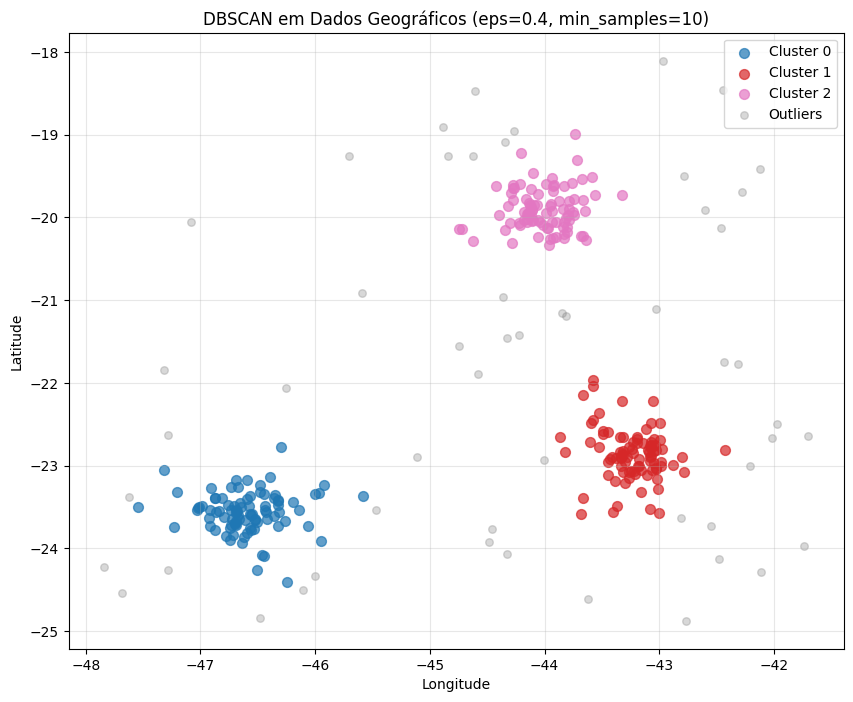

In [18]:
# Visualizar melhor resultado
best_eps = 0.4
best_min_samples = 10
# best_eps = 0.8
# best_min_samples = 5
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_geo)

# Plot com cores
plt.figure(figsize=(10, 8))
unique_labels = set(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = (labels == label)
    if label == -1:
        color = 'gray'
        label = 'Outliers'
        size = 30
        alpha = 0.3
    else:
        label = f'Cluster {label}'
        size = 50
        alpha = 0.7

    plt.scatter(X_geo[mask, 1], X_geo[mask, 0],
               c=[color], label=label, s=size, alpha=alpha)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"DBSCAN em Dados Geográficos (eps={best_eps}, min_samples={best_min_samples})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##Exercícios
1. **Por que o DBSCAN funciona melhor que K-Means nesses formatos?**
2. **Qual combinação de parâmetros foi melhor para cada formato?**
3. **O que acontece com o eps quando aumentamos o min_samples?**
3. **Como a escolha de parâmetros afeta o número de clusters?**
1. **Como a alta dimensionalidade afeta o DBSCAN?**
2. **Qual a importância da padronização?**
3. **Por que muitos pontos podem ser classificados como outliers?**
3. **O que os outliers representam neste contexto?**
2. **Por que não precisamos padronizar dados geográficos?**
3. **Como usar esses resultados para planejamento urbano?**